In [1]:
#!git clone https://github.com/Rorschach1989/nfm.git

Cloning into 'nfm'...
remote: Enumerating objects: 694, done.
remote: Counting objects: 100% (381/381), done.
remote: Compressing objects: 100% (240/240), done.
remote: Total 694 (delta 250), reused 232 (delta 139), pack-reused 313 (from 1)
Receiving objects: 100% (694/694), 3.58 MiB | 5.74 MiB/s, done.
Resolving deltas: 100% (471/471), done.


In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader
from nfm.nfm.DatasetsDHS import SurvivalDataset
from nfm.nfm.base import MonotoneNLL
from nfm.nfm.eps_config import IGGEps
from nfm.nfm.metric import c_index
from nfm.nfm.utils import default_device
from pycox.evaluation.eval_surv import EvalSurv


data_full = SurvivalDataset.SouthAfrica('./nfm/data/SouthAfrica_cleanednew.csv')
fold_c_indices = []
fold_survival =  []
fold_ibs = []
fold_nbll = []
normalizing_factor = 366.25


def normalize(y):
    return (y + 1) / normalizing_factor


n_hidden = 128
n_hidden_umnn = 128


for i in tqdm(range(5)):
    torch.manual_seed(77+i)
    train_folds, valid_folds, test_folds = data_full.cv_split(shuffle=True)
    for i in range(5):
        test_c_indices, test_ibs, test_nbll = [], [], []
        valid_losses = []
        m = nn.Sequential(
            nn.Linear(in_features=737, out_features=n_hidden, bias=False),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features=n_hidden, out_features=1, bias=False),
        ).to(default_device)
        nll = MonotoneNLL(eps_conf=IGGEps(),
                          num_hidden_units=n_hidden_umnn,
                          positive_transform='exp').to(default_device)
        optimizer = torch.optim.Adam(lr=1e-3, weight_decay=1e-2, params=list(m.parameters()) + list(nll.parameters()))
        loader = DataLoader(train_folds[i], batch_size=256)
        for epoch in range(30):
            for z, y, delta in loader:
                m.train()
                m_z = m(z)
                loss = nll(m_z=m_z, y=normalize(y), delta=delta)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            m.eval()
            with torch.no_grad():
                y_valid, delta_valid, z_valid = valid_folds[i].sort()
                y_test, delta_test, z_test = test_folds[i].sort()
                y_valid, y_test = normalize(y_valid), normalize(y_test)
                pred_valid = m(z_valid)
                pred_test = m(z_test)
                valid_loss = nll(pred_valid, y_valid, delta_valid)
                valid_losses.append(valid_loss)
                tg_test = np.linspace(y_test.cpu().numpy().min(), y_test.cpu().numpy().max(), 60)
                surv_pred_test = nll.get_survival_prediction(
                    pred_test, y_test=torch.tensor(tg_test, dtype=torch.float).view(-1, 1))
                test_evaluator = EvalSurv(
                    surv=pd.DataFrame(surv_pred_test.cpu().numpy(), index=tg_test.reshape(-1)),
                    durations=y_test.cpu().numpy().reshape(-1),
                    events=delta_test.cpu().numpy().reshape(-1),
                    censor_surv='km')
                test_c_indices.append(c_index(-pred_test, y_test, delta_test))
                test_ibs.append(test_evaluator.integrated_brier_score(time_grid=tg_test))
                test_nbll.append(test_evaluator.integrated_nbll(time_grid=tg_test))
        valid_argmin = np.argmin(valid_losses)
        fold_survival.append(np.asarray(surv_pred_test)[valid_argmin])
        fold_c_indices.append(np.asarray(test_c_indices)[valid_argmin])
        fold_ibs.append(np.asarray(test_ibs)[valid_argmin])
        fold_nbll.append(np.asarray(test_nbll)[valid_argmin])


report_str = f"""
Results:
    mean survival: {np.asarray(fold_survival).mean()}
    mean c-index: {np.asarray(fold_c_indices).mean()}
    std c-index: {np.asarray(fold_c_indices).std()}
    mean ibs: {np.asarray(fold_ibs).mean()}
    std ibs: {np.asarray(fold_ibs).std()}
    mean ibll: {np.asarray(fold_nbll).mean()}
    std ibll: {np.asarray(fold_nbll).std()}
"""
print(report_str)


/home/justine/miniconda3/envs/py37/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                             | 0/5 [00:00<?, ?it/s]/home/justine/nfm/nfm/DatasetsDHS.py:313: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float, device=default_device).view(-1, 1)
/home/justine/nfm/nfm/DatasetsDHS.py:314: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.delta = torch.tensor(delta, dtype=torch.float, d


Results:
    mean survival: 0.9873127341270447
    mean c-index: 0.8385074138641357
    std c-index: 0.08192186802625656
    mean ibs: 0.016923360331147917
    std ibs: 0.002635841788369727
    mean ibll: 0.07941904912914438
    std ibll: 0.01223639084005369



In [3]:
df = pd.DataFrame(fold_survival).transpose()
df.to_csv("FULL_fold_survival_SouthAfricaNEW2", index=False)
df = pd.DataFrame(surv_pred_test_T_np)
df.to_csv('SouthAfrica_resultssurvivalFULLNEW2.csv', index=False)
df = pd.DataFrame(fold_ibs, columns=['fold_ibs'])
df.to_csv('fold_ibsFULLdataSouthAfricasresultsNEW2.csv', index=False)
df = pd.DataFrame(fold_c_indices, columns=['fold_c_indices'])
df.to_csv('fold_c_indicesFULLdataSouthAfricasresultsNEW2.csv', index=False)

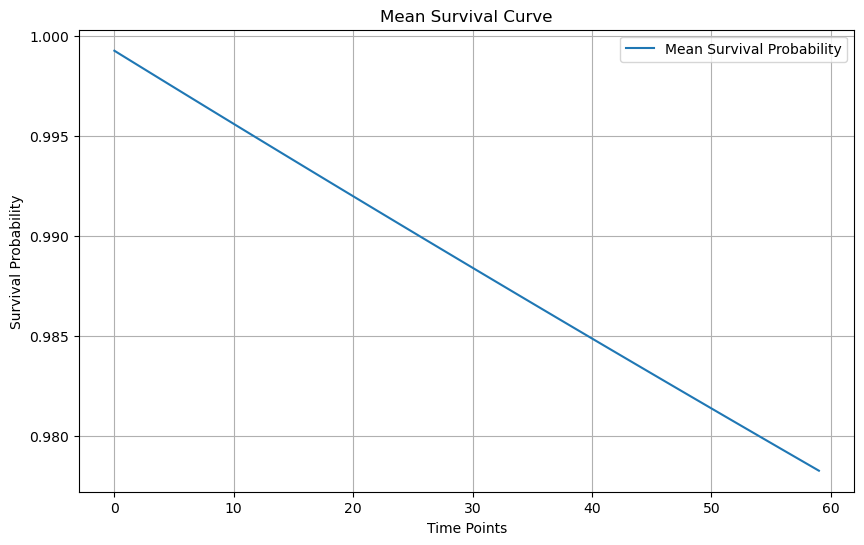

In [2]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()


No handles with labels found to put in legend.


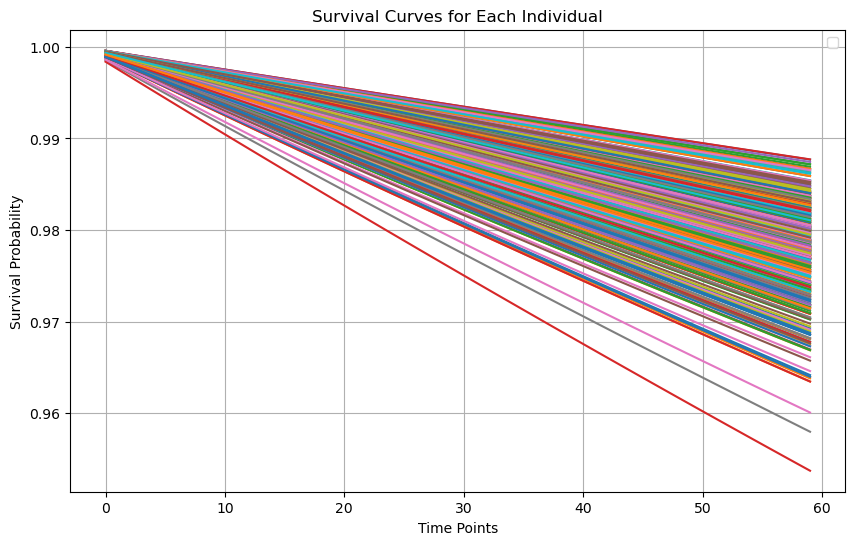

In [4]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T

# Plot each individual's survival curve
plt.figure(figsize=(10, 6))
for i in range(surv_pred_test_T.shape[0]):
    plt.plot(np.arange(surv_pred_test_T.shape[1]), surv_pred_test_T[i])

plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Each Individual')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Values')

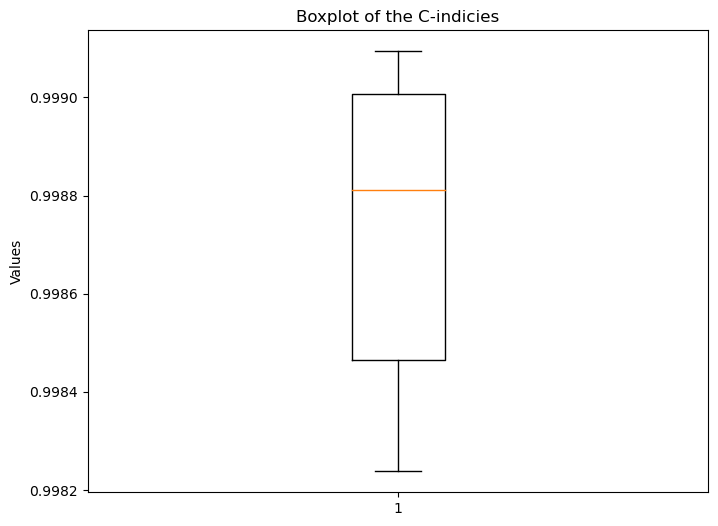

In [4]:

plt.figure(figsize=(8,6))
plt.boxplot(fold_c_indices)
plt.title('Boxplot of the C-indicies')
plt.ylabel('Values')


Text(0, 0.5, 'Values')

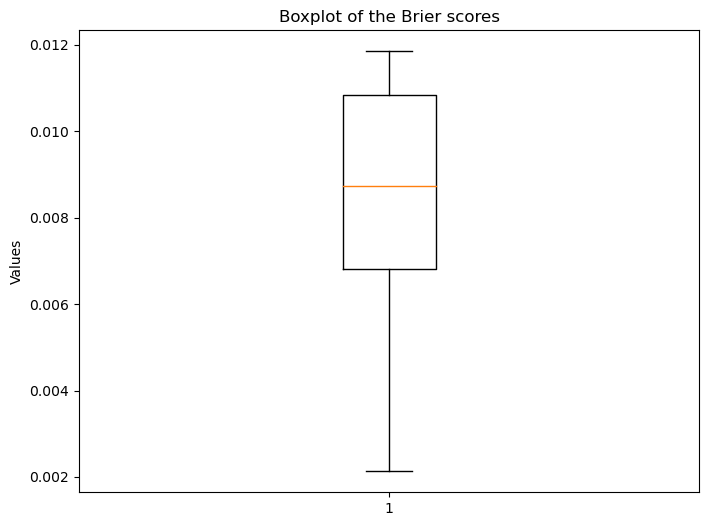

In [5]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_ibs)
plt.title('Boxplot of the Brier scores')
plt.ylabel('Values')


50

In [10]:
#train_folds
#valid_folds
#test_folds
#loader

No handles with labels found to put in legend.


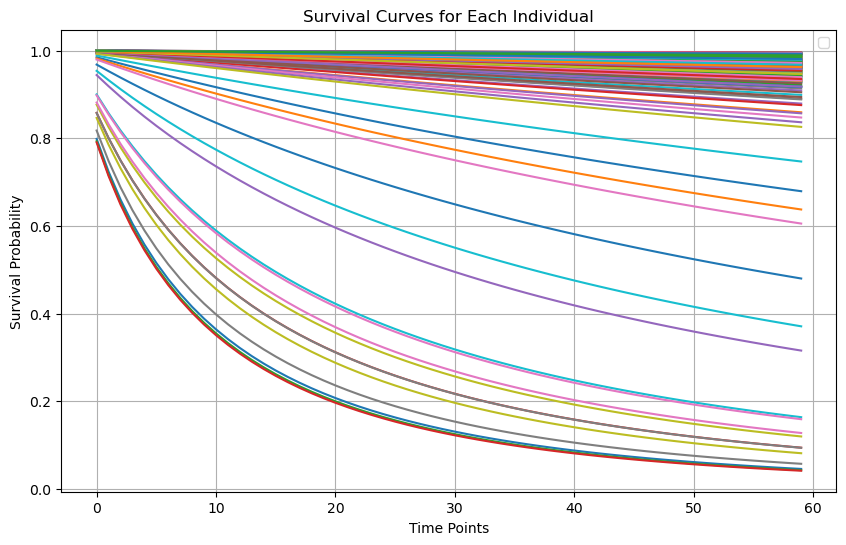

In [32]:
import matplotlib.pyplot as plt
surv_pred_test_T = surv_pred_test.T

# Plot each individual's survival curve
plt.figure(figsize=(10, 6))
for i in range(surv_pred_test_T.shape[0]):
    plt.plot(np.arange(surv_pred_test_T.shape[1]), surv_pred_test_T[i])

plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Survival Curves for Each Individual')
plt.legend()
plt.grid(True)
plt.show()

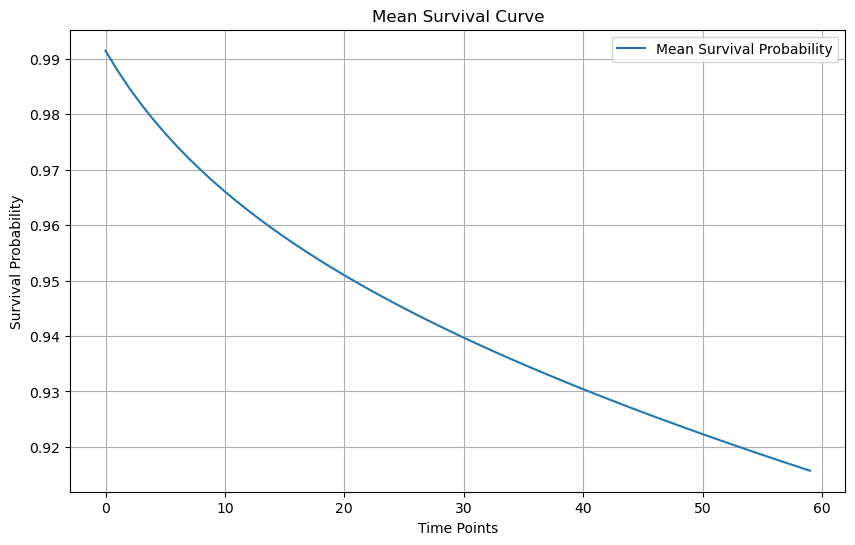

In [33]:
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()

Text(0, 0.5, 'Values')

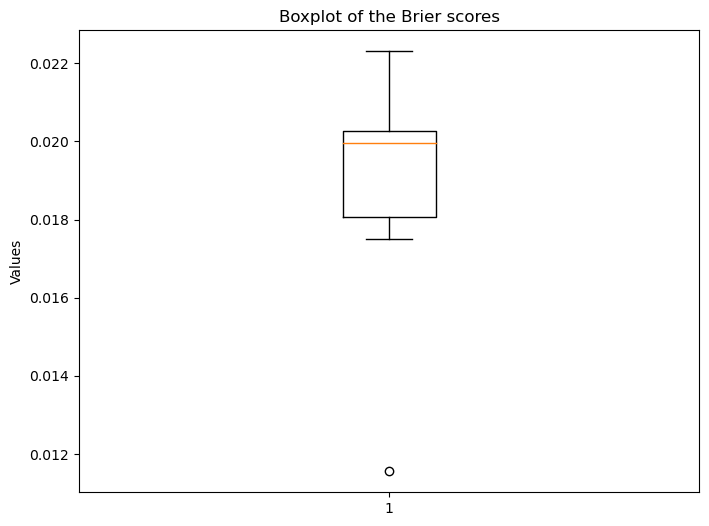

In [34]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_ibs)
plt.title('Boxplot of the Brier scores')
plt.ylabel('Values')

Text(0, 0.5, 'Values')

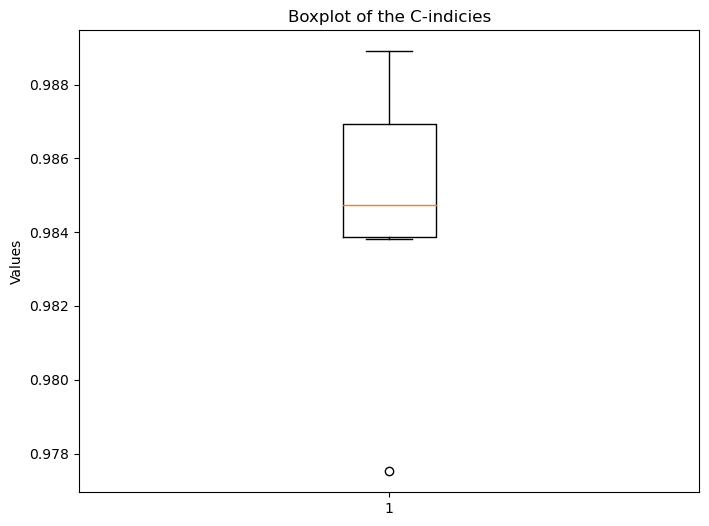

In [35]:
plt.figure(figsize=(8,6))
plt.boxplot(fold_c_indices)
plt.title('Boxplot of the C-indicies')
plt.ylabel('Values')

In [31]:
#!pip install tqdm

In [2]:
import pandas as pd

df = pd.read_csv('./nfm/data/SA2016Analysis.csv')
print(df.columns)

Index(['CASEID', 'V001', 'MIDX', 'survival_time', 'Status', 'B4',
       'Mother_education', 'husband_education', 'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M4_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode', 'V206_recode',
       'V209_recode', 'M18_recode', 'V151'],
      dtype='object')


In [3]:
df.shape[0]

3401

In [4]:
df

,CASEID,V001,MIDX,survival_time,Status,B4,Mother_education,husband_education,age_group,age_first_birth,...,M4_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V206_recode,V209_recode,M18_recode,V151
0,1282,1,1,53.979466,0,Female,Complete Secondary,Complete Secondary,40+,20-29,...,NaN,No,Energies,2,No,4+,NaN,No,Average,Male
1,1282,1,2,53.979466,0,Female,Complete Secondary,Complete Secondary,40+,20-29,...,NaN,No,Energies,2,No,4+,NaN,No,Average,Male
2,1362,1,1,51.318275,0,Male,Complete Secondary,Complete Secondary,20-29,20-29,...,NaN,No,Energies,0,Yes,2,NaN,No,Average,Male
3,1932,1,1,44.123203,0,Male,Complete Secondary,NaN,20-29,below 20,...,NaN,No,Energies,0,No,2,NaN,No,Average,Male
4,2344,2,1,29.864476,0,Female,Complete Secondary,Complete Secondary,20-29,below 20,...,NaN,No,Energies,2,No,4+,NaN,No,Average,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3396,750322,750,2,52.402464,0,Female,Complete Primary,NaN,20-29,below 20,...,NaN,No,Energies,2,Yes,4+,NaN,No,Average,Female
3397,750482,750,1,2.000000,1,Female,None,NaN,40+,below 20,...,NaN,No,Energies,1,No,4+,NaN,No,Large,Male
3398,750482,750,2,52.501027,0,Male,None,NaN,40+,below 20,...,NaN,No,Energies,1,No,4+,NaN,No,Large,Male
3399,750672,750,1,32.262834,0,Male,None,Complete Primary,30-39,below 20,...,NaN,No,Energies,2,No,4+,NaN,No,Large,Male


In [5]:
file_path = './nfm/data/SA2016Analysis.csv'

# Reading the CSV file
data_full = pd.read_csv(file_path)
data_full = pd.read_csv(file_path)
features_to_remove = ['Mother_education', 'husband_education', 'V206_recode', 'M4_recode']
data_cleaned = data_full.drop(columns=features_to_remove)
SouthAfrica =data_cleaned.dropna()

In [6]:
data_full.shape[0]

3401

In [7]:
SouthAfrica.shape[0]

2760

In [8]:
SouthAfrica.to_csv('SouthAfrica_cleaned.csv', index=False)

In [12]:
import pandas as pd

# Load the SA dataset

file_path = 'nfm/data/SouthAfrica_cleaned.csv'
SouthAfrica_df = pd.read_csv(file_path)

# Predefined encoding maps
age_group_encoding = {
    'below 20': 0, 
    '20-29': 1, 
    '30-39': 2, 
    '40+': 3
}

age_first_birth_encoding = {
    'below 20': 0, 
    '20-29': 1, 
    '30+': 2
}

drinking_water_source_encoding = {
    'Piped water': 0, 
    'Borehole': 1, 
    'Well': 2, 
    'Surface/rain/pond/lake/tank': 3, 
    'Other': 4
}

Bord_recoded_encoding = { 
    '1': 1, 
    '2-3': 2, 
    '4-6': 3,
    '7+' : 4
}

V218_recoded_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

V201_recoded_encoding = {
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

V605_recode_encoding = {
    'No': 0, 
    'Yes': 1,
    'Undecided/Never had sex' : 3
}

V130_recode_encoding = { 
    'Christians': 1, 
    'Muslim': 2, 
    'Others': 3
}

M70_recode_encoding = {
    'No': 0, 
    'Yes': 1
}

V137_recode_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

B4_recode_encoding = {
    'Female': 0, 
    'Male': 1 
}

V404_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V213_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V405_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V502_recode_encoding = {
    'Never in union': 0, 
    'Currently in union/living with a man': 1,
    'Formerly in union/living with a man': 2
}

V190_recode_encoding = {
    'Poorest': 0, 
    'Poorer': 1, 
    'Middle': 2, 
    'Richer': 3, 
    'Richest': 4
}



M3A_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V161_recode_encoding = {
    'Others': 0, 
    'Energies': 1, 
    'Biomass or Solid fuels': 2, 
    'Kerosine': 3
}

V716_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

V136_recode_encoding = {
    '0': 0, 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}


V209_recode_encoding = {
    'No': 0, 
    'Yes': 1 
}

M18_recode_encoding = {
    'Small': 0, 
    'Average': 1,
    'Large' : 2
}

V151_recode_encoding = {
    'Female': 0, 
    'Male': 1 
}

V208_recode_encoding = { 
    '1': 1, 
    '2': 2, 
    '3': 3, 
    '4+': 4
}

# Function to apply predefined encoding to columns
def apply_predefined_encoding(df, column, encoding_map, default_value=4):
    if column in df.columns:
        df[column] = df[column].map(encoding_map).fillna(default_value).astype(int)
    return df


# Apply encodings
#SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'Mother_education', Mother_education_encoding)
#SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'husband_education', husband_education_encoding, default_value=5)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'age_group', age_group_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'age_first_birth', age_first_birth_encoding, default_value=2)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'drinking_water_source', drinking_water_source_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'BORD_recoded', Bord_recoded_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V218_recoded', V218_recoded_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V201_recoded', V201_recoded_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V605_recode', V605_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V130_recode', V130_recode_encoding, default_value=3)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'M70_recode', M70_recode_encoding, default_value=2)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V404', V404_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'B4', B4_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V213', V213_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V405', V405_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V502', V502_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V190', V190_recode_encoding)
#SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'M4_recode', M4_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'M3A', M3A_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V161_recode', V161_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V716_working', V716_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V136_recode', V136_recode_encoding)
#SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V206_recode', V206_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V209_recode', V209_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'M18_recode', M18_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V151', V151_recode_encoding)
SouthAfrica_df = apply_predefined_encoding(SouthAfrica_df, 'V208_recoded', V208_recode_encoding)

# Update column names
SouthAfrica_df.columns = ['CASEID', 'V001', 'MIDX', 'survival_time', 'Status', 'B4',
        'age_group', 'age_first_birth',
       'drinking_water_source', 'BORD_recoded', 'V208_recoded', 'V404', 'V213',
       'V405', 'V218_recoded', 'V502', 'V190', 'V201_recoded', 'V605_recode',
       'V130_recode', 'M70_recode', 'M3A', 'V161_recode',
       'V137_recode', 'V716_working', 'V136_recode',
       'V209_recode', 'M18_recode', 'V151']

# Display the preprocessed dataset
SouthAfrica_df.head()


,CASEID,V001,MIDX,survival_time,Status,B4,age_group,age_first_birth,drinking_water_source,BORD_recoded,...,V130_recode,M70_recode,M3A,V161_recode,V137_recode,V716_working,V136_recode,V209_recode,M18_recode,V151
0,1282,1,1,53.979466,0,0,3,1,0,2,...,3,1,0,1,2,0,4,0,1,1
1,1362,1,1,51.318275,0,1,1,1,0,1,...,3,0,0,1,0,1,2,0,1,1
2,1932,1,1,44.123203,0,1,1,0,0,1,...,3,1,0,1,0,0,2,0,1,1
3,2344,2,1,29.864476,0,0,1,0,0,2,...,3,1,0,1,2,0,4,0,1,0
4,2502,2,1,5.782341,0,1,0,0,0,1,...,3,0,0,1,1,0,4,1,1,0


In [14]:
SouthAfrica_df.to_csv('SouthAfrica_cleanednew.csv', index=False)

In [13]:
SouthAfrica_df.shape[0]

2760

In [ ]:
df = pd.DataFrame(fold_ibs, columns=['fold_ibs'])
df.to_csv('fold_ibsSouthAfrica_cleanednewfold_ibsresults.csv', index=False)

In [ ]:
df = pd.DataFrame(fold_c_indices, columns=['fold_c_indices'])
df.to_csv('fold_c_indicesSouthAfrica_cleanednewcindexresults.csv', index=False)

In [ ]:
surv_pred_test_T_np = surv_pred_test_T.detach().cpu().numpy() if not isinstance(surv_pred_test_T, np.ndarray) else surv_pred_test_T
mean_surv_prob = np.mean(surv_pred_test_T_np, axis=0)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(surv_pred_test_T_np.shape[1]), mean_surv_prob, label='Mean Survival Probability')
plt.xlabel('Time Points')
plt.ylabel('Survival Probability')
plt.title('Mean Survival Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame(surv_pred_test_T_np)

In [ ]:
df.to_csv('SouthAfrica_cleanednewsurvivalresults.csv', index=False)